In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from ema_workbench.analysis import pairs_plotting
from ema_workbench.analysis import feature_scoring
from tqdm import tqdm

from sklearn.preprocessing import StandardScaler, LabelEncoder

from scipy.spatial import distance
from scipy.cluster import hierarchy

import warnings
from sklearn import tree
from pprint import pprint 
import graphviz
import sklearn
import dtreeviz

from collections import Counter
from collections import deque
import os
import sys
sys.path.insert(0, '..')

from example_archspace import ToyExample
from archspace import show_pairplot, show_feature_scores, show_outcome_distributions, show_tradeoff_distribution
from archspace import show_quality_attribute_space2D, show_configuration_space2D

In [3]:
my_space = ToyExample()
my_space.create_model('toy_example')

experiments_df, outcomes_df = my_space.load_results('./data/archexploration_500scenarios_400policies_ff.tar.gz')

print(len(my_space.get_configurations()), "configurations")
print("Configurations:", my_space.get_configurations())

Removing void architecture! (171500, 12) 343
342 configurations
Configurations: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 20

In [4]:
experiments_df

,deviceCPUCyles,deviceCost,lbExecTime,lbFailureProb,serviceCost,serviceFailureProb,d1Services,d2Services,d3Services,scenario,policy,model
0,109,23,49,27,5,18,0,0,1,343,1,archexploration
1,138,15,18,22,4,10,0,0,1,344,1,archexploration
2,104,21,44,30,3,48,0,0,1,345,1,archexploration
3,109,12,11,15,3,36,0,0,1,346,1,archexploration
4,147,13,11,18,1,27,0,0,1,347,1,archexploration
...,...,...,...,...,...,...,...,...,...,...,...,...
170995,105,1,22,16,5,11,6,6,6,838,342,archexploration
170996,125,36,13,14,3,17,6,6,6,839,342,archexploration
170997,114,17,27,17,5,49,6,6,6,840,342,archexploration
170998,107,14,11,28,5,30,6,6,6,841,342,archexploration


In [6]:
experiments_df.to_csv('experiments.csv', index=False)

In [4]:
experiments_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 171000 entries, 0 to 170999
Data columns (total 12 columns):
 #   Column              Non-Null Count   Dtype   
---  ------              --------------   -----   
 0   deviceCPUCyles      171000 non-null  int64   
 1   deviceCost          171000 non-null  int64   
 2   lbExecTime          171000 non-null  int64   
 3   lbFailureProb       171000 non-null  int64   
 4   serviceCost         171000 non-null  int64   
 5   serviceFailureProb  171000 non-null  int64   
 6   d1Services          171000 non-null  int64   
 7   d2Services          171000 non-null  int64   
 8   d3Services          171000 non-null  int64   
 9   scenario            171000 non-null  category
 10  policy              171000 non-null  category
 11  model               171000 non-null  category
dtypes: category(3), int64(9)
memory usage: 12.6 MB


In [5]:
print(set(experiments_df['policy']))

{1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 22

In [6]:
# It takes significant time!
# embeddings_df = show_configuration_space2D(experiments_df, alpha=0.7, legend=False)

In [5]:
outcomes_df

,cost,executionTime,probSuccessfulExecution
0,28,94,60
1,19,81,71
2,24,72,37
3,15,46,55
4,14,65,60
...,...,...,...
170995,93,38,84
170996,162,31,86
170997,141,37,74
170998,132,24,71


In [7]:
outcomes_df.to_csv('outcomes.csv', index=False)

In [9]:
merged_df = pd.concat([experiments_df, outcomes_df], axis=1)
merged_df.to_csv('merged.csv', index=False)

In [8]:
outcomes_df.describe()

,cost,executionTime,probSuccessfulExecution
count,171000.000000,171000.000000,171000.000000
mean,78.652737,48.877789,65.293895
std,39.993494,14.227972,12.421094
min,1.000000,22.000000,26.000000
25%,47.000000,38.000000,55.000000
50%,75.000000,48.000000,65.000000
75%,106.000000,59.000000,75.000000
max,210.000000,114.000000,90.000000


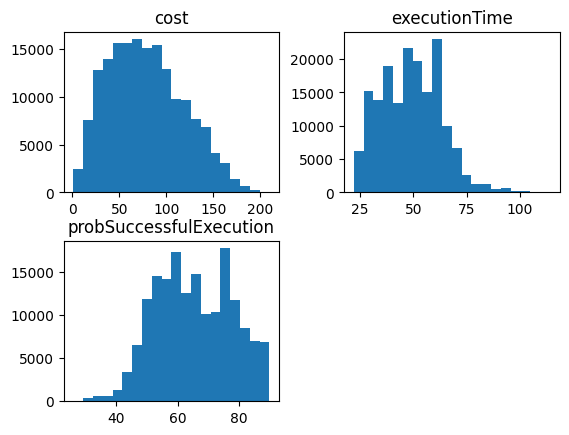

In [9]:
# outcomes
outcomes_df.hist(bins=20, grid=False)
plt.show()

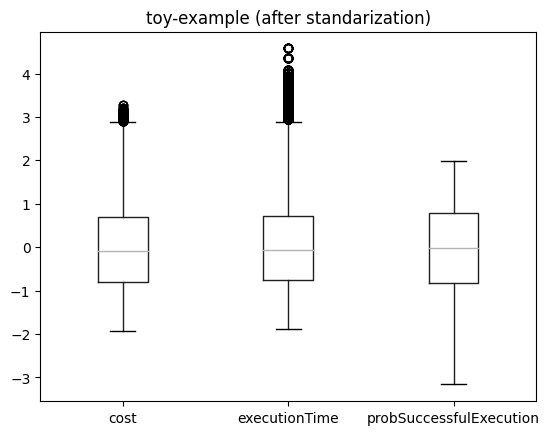

In [10]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(outcomes_df)
scaled_df = pd.DataFrame(scaled_data, columns=outcomes_df.columns)
scaled_df.boxplot(grid=False)
plt.title('toy-example (after standarization)')
plt.show()

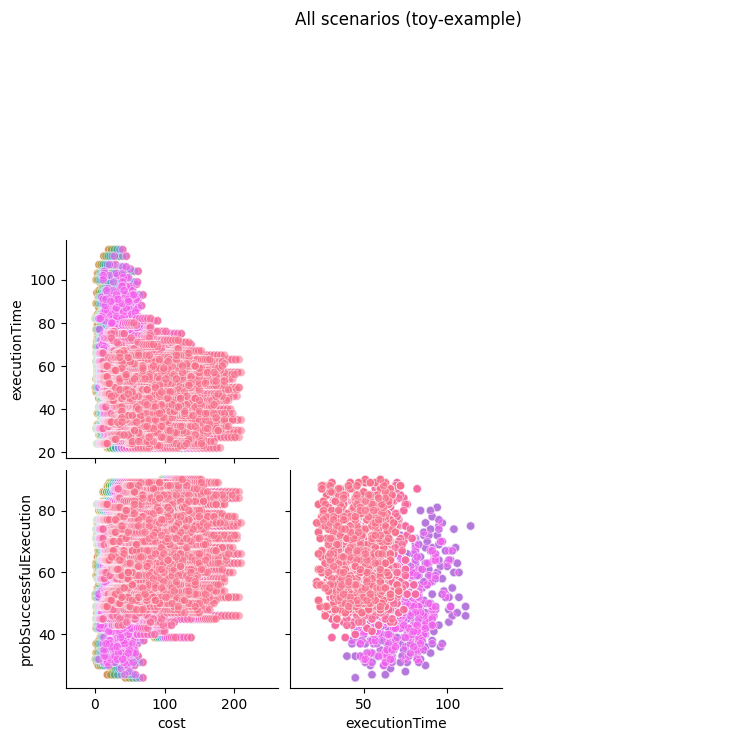

In [11]:
# show_pairplot(my_space, title='All scenarios (toy-example)', kind='sns')
show_pairplot(my_space, title='All scenarios (toy-example)', kind='sns', group='policy', legend=False) #, filename=None)
# show_pairplot(my_space, title='All scenarios (toy-example)', kind='sns', group='scenario', legend=False) #, filename=None)

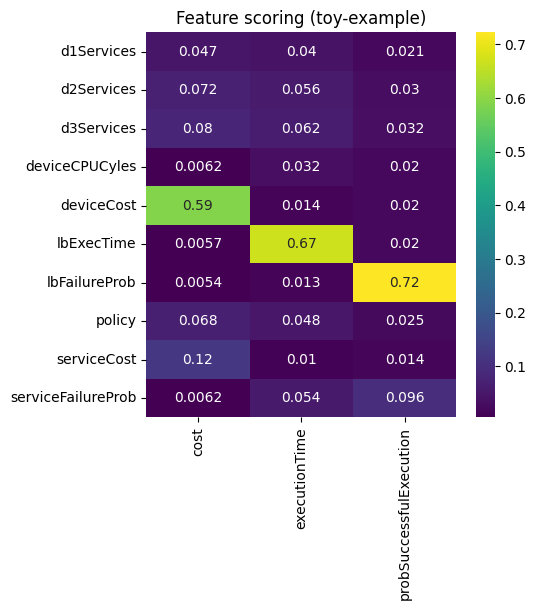

,cost,executionTime,probSuccessfulExecution
0,,,
d1Services,0.047303,0.040348,0.020510
d2Services,0.071611,0.056402,0.029885
d3Services,0.079511,0.062325,0.032140
deviceCPUCyles,0.006234,0.031816,0.019542
deviceCost,0.590753,0.013610,0.020339
lbExecTime,0.005741,0.668898,0.020307
lbFailureProb,0.005432,0.013492,0.722446
policy,0.067507,0.048444,0.024991
serviceCost,0.119714,0.010469,0.014304


In [12]:
policy_size = (5,5)
# filter_params = PipesAndFilters.COMMON_PARAMETERS
fs = show_feature_scores(my_space, title='Feature scoring (toy-example)', size=policy_size) #, parameters=filter_params) #, filename=None)  
fs

In [13]:
kp = list(fs.query('(cost > 0.1) or (executionTime > 0.1) or (probSuccessfulExecution > 0.1)').index)
fs.query('(cost > 0.1) or (executionTime > 0.1) or (probSuccessfulExecution > 0.1)')

,cost,executionTime,probSuccessfulExecution
0,,,
deviceCost,0.590753,0.013610,0.020339
lbExecTime,0.005741,0.668898,0.020307
lbFailureProb,0.005432,0.013492,0.722446
serviceCost,0.119714,0.010469,0.014304


In [14]:
my_policies = my_space.get_configurations()
# my_policies

Absolute ranges: [(1.0, 210.0), (22.0, 114.0), (26.0, 90.0)]
cost [0.9, 70.63333333333334, 140.36666666666667, 210.1]
executionTime [21.9, 52.633333333333326, 83.36666666666666, 114.1]
probSuccessfulExecution [25.9, 47.3, 68.69999999999999, 90.1]


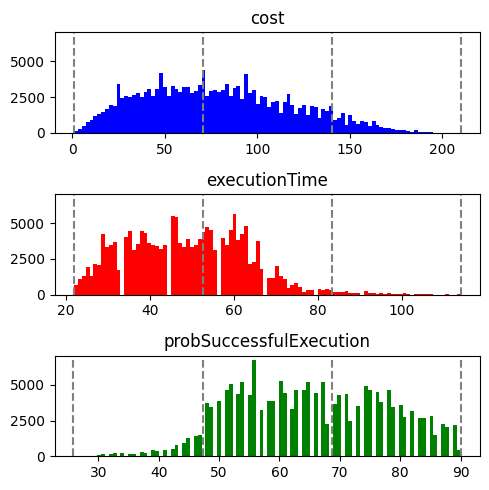

{'cost': [0.9, 70.63333333333334, 140.36666666666667, 210.1],
 'executionTime': [21.9, 52.633333333333326, 83.36666666666666, 114.1],
 'probSuccessfulExecution': [25.9, 47.3, 68.69999999999999, 90.1]}

In [15]:
MIN_LATENCY, MAX_LATENCY = (22.0, 114.0)
MIN_AVAILABIITY, MAX_AVAILABILITY = (26.0, 90.0)
MIN_COST, MAX_COST = (1.0, 210.0)

MIN_MAX_RANGES = [(MIN_COST,  MAX_COST), (MIN_LATENCY, MAX_LATENCY), (MIN_AVAILABIITY, MAX_AVAILABILITY)]
print('Absolute ranges:', MIN_MAX_RANGES)

show_outcome_distributions(my_space, mins_maxs=MIN_MAX_RANGES, size=(5,5), labels=3)

In [16]:
my_space.OUTPUTS

['cost', 'executionTime', 'probSuccessfulExecution']

In [17]:
_ = my_space.discretize_outcomes(mins_maxs=MIN_MAX_RANGES)
print("Experiments:", experiments_df.shape)

config = 1 # Arbitrary configuration -- should it be a string?
exp_df, out_df, discrete_out_df = my_space.get_experiment(config)

# print(exp_df.head())
# print(out_df.head())
# print(discrete_exp_df)
print(my_space.available_tradeoffs_)
print("Tradeoffs for ", config,"-->", ToyExample.get_tradeoffs(discrete_out_df))
discrete_out_df.head(10)

Experiments: (171000, 12)
Counter({'average,fast,average': 27007, 'cheap,fast,average': 24849, 'average,fast,unreliable': 19794, 'cheap,average,average': 15825, 'average,average,average': 15795, 'cheap,fast,unreliable': 15547, 'cheap,average,unreliable': 14079, 'average,average,unreliable': 13758, 'expensive,fast,average': 4934, 'expensive,fast,unreliable': 4079, 'cheap,average,highly-reliable': 3690, 'expensive,average,unreliable': 2655, 'cheap,fast,highly-reliable': 2135, 'expensive,average,average': 1842, 'average,fast,highly-reliable': 1382, 'cheap,slow,average': 1206, 'cheap,slow,highly-reliable': 846, 'average,average,highly-reliable': 756, 'expensive,fast,highly-reliable': 443, 'cheap,slow,unreliable': 378})
Tradeoffs for  1 --> Counter({'cheap,average,highly-reliable': 169, 'cheap,average,average': 143, 'cheap,slow,average': 67, 'cheap,slow,highly-reliable': 47, 'cheap,fast,highly-reliable': 34, 'cheap,slow,unreliable': 21, 'cheap,average,unreliable': 14, 'cheap,fast,average': 

,cost,executionTime,probSuccessfulExecution
0,cheap,slow,average
1,cheap,average,unreliable
2,cheap,average,highly-reliable
3,cheap,fast,average
4,cheap,average,average
5,cheap,average,average
6,cheap,average,average
7,cheap,average,unreliable
8,cheap,average,highly-reliable
9,cheap,average,highly-reliable


In [18]:
my_space.available_tradeoffs_

Counter({'average,fast,average': 27007,
         'cheap,fast,average': 24849,
         'average,fast,unreliable': 19794,
         'cheap,average,average': 15825,
         'average,average,average': 15795,
         'cheap,fast,unreliable': 15547,
         'cheap,average,unreliable': 14079,
         'average,average,unreliable': 13758,
         'expensive,fast,average': 4934,
         'expensive,fast,unreliable': 4079,
         'cheap,average,highly-reliable': 3690,
         'expensive,average,unreliable': 2655,
         'cheap,fast,highly-reliable': 2135,
         'expensive,average,average': 1842,
         'average,fast,highly-reliable': 1382,
         'cheap,slow,average': 1206,
         'cheap,slow,highly-reliable': 846,
         'average,average,highly-reliable': 756,
         'expensive,fast,highly-reliable': 443,
         'cheap,slow,unreliable': 378})

In [19]:
X_train, X_test, y_train, y_test = my_space.split_dataset(test_size=0.3)
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(171000, 15) 171000
Instances to remove (not enough tradeoffs): set()
{'cheap,slow,highly-reliable', 'cheap,fast,unreliable', 'cheap,fast,highly-reliable', 'cheap,fast,average', 'cheap,slow,average', 'expensive,average,unreliable', 'cheap,slow,unreliable', 'average,fast,average', 'average,average,average', 'expensive,fast,average', 'cheap,average,unreliable', 'average,fast,unreliable', 'average,average,highly-reliable', 'average,fast,highly-reliable', 'expensive,fast,highly-reliable', 'cheap,average,average', 'expensive,average,average', 'expensive,fast,unreliable', 'average,average,unreliable', 'cheap,average,highly-reliable'}
(171000, 15) 171000
(119700, 15) (119700, 3) (51300, 15) (51300, 3)


In [20]:
my_space.import_dataset(X_train, y_train)

In [21]:
print("Computing robustness for all configurations...")
df = my_space.compute_robustness_matrix()
# df.to_csv('./data/toyexample_robustness_matrix.csv')

# sns.heatmap(df, annot=True, fmt=".2f", cmap='flare')
# plt.show()
df

Computing robustness for all configurations...


100%|██████████| 342/342 [01:02<00:00,  5.49it/s]


,1,2,3,4,5,6,7,8,9,10,...,333,334,335,336,337,338,339,340,341,342
"average,average,average",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.038462,0.066482,0.067989,...,0.089337,0.085714,0.078212,0.146132,0.093484,0.096591,0.080357,0.083832,0.084746,0.075676
"average,average,highly-reliable",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.011834,0.008310,0.014164,...,0.000000,0.000000,0.000000,0.011461,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
"average,average,unreliable",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.047337,0.049861,0.045326,...,0.080692,0.100000,0.081006,0.126074,0.093484,0.096591,0.089286,0.074850,0.073446,0.100000
"average,fast,average",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.065089,0.072022,0.079320,...,0.204611,0.168571,0.226257,0.157593,0.201133,0.204545,0.214286,0.209581,0.200565,0.183784
"average,fast,highly-reliable",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.008876,0.008310,0.008499,...,0.002882,0.000000,0.002793,0.028653,0.002833,0.002841,0.000000,0.002994,0.002825,0.002703
"average,fast,unreliable",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.023669,0.036011,0.031161,...,0.161383,0.160000,0.153631,0.083095,0.150142,0.176136,0.142857,0.179641,0.161017,0.162162
"cheap,average,average",0.275148,0.279762,0.302260,0.283333,0.277937,0.275568,0.285294,0.221893,0.188366,0.203966,...,0.028818,0.028571,0.025140,0.103152,0.045326,0.019886,0.026786,0.026946,0.025424,0.024324
"cheap,average,highly-reliable",0.334320,0.318452,0.313559,0.325000,0.366762,0.332386,0.329412,0.014793,0.011080,0.014164,...,0.000000,0.000000,0.000000,0.011461,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
"cheap,average,unreliable",0.026627,0.026786,0.031073,0.033333,0.020057,0.025568,0.029412,0.171598,0.174515,0.147309,...,0.051873,0.042857,0.044693,0.117479,0.053824,0.051136,0.047619,0.047904,0.042373,0.032432
"cheap,fast,average",0.011834,0.011905,0.011299,0.011111,0.008596,0.011364,0.005882,0.233728,0.252078,0.237960,...,0.097983,0.111429,0.067039,0.126074,0.110482,0.099432,0.107143,0.104790,0.076271,0.078378


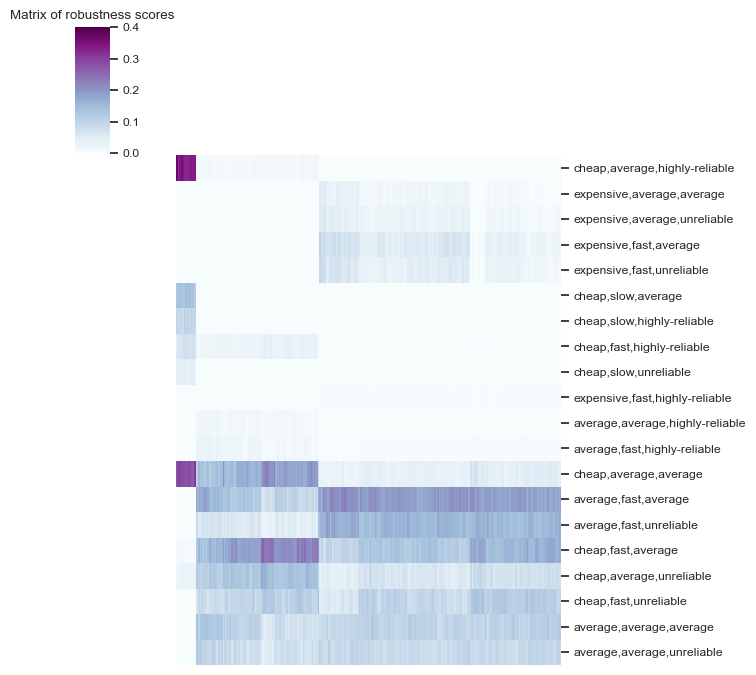

In [22]:
correlations_array = df.values
row_linkage = hierarchy.linkage(distance.pdist(correlations_array), method='average')
col_linkage = hierarchy.linkage(distance.pdist(correlations_array.T), method='average')

sns.set(font_scale=0.8)
ax = sns.clustermap(df, row_linkage=row_linkage, col_linkage=col_linkage, 
                    vmax=0.4, vmin=0, method="average", figsize=(7, 7), cmap="BuPu")
ax.ax_row_dendrogram.set_visible(False)
ax.ax_col_dendrogram.set_visible(False)
ax.ax_heatmap.set_xticklabels([])
plt.title("Matrix of robustness scores")
plt.show()

In [23]:
df.describe()

,1,2,3,4,5,6,7,8,9,10,...,333,334,335,336,337,338,339,340,341,342
count,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,...,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000
mean,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,...,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.050000
std,0.096257,0.094301,0.095941,0.095356,0.101162,0.095438,0.095967,0.075806,0.074185,0.072354,...,0.057190,0.053777,0.058557,0.058733,0.056764,0.059900,0.057489,0.059462,0.055960,0.055358
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.013314,0.009695,0.014164,...,0.041787,0.044286,0.047486,0.015759,0.039660,0.029830,0.043155,0.041916,0.045198,0.040541
75%,0.044379,0.050595,0.049435,0.046528,0.043696,0.055398,0.054412,0.051775,0.067867,0.070822,...,0.074207,0.081429,0.074022,0.106734,0.074363,0.079545,0.080357,0.065868,0.077684,0.080405
max,0.334320,0.318452,0.313559,0.325000,0.366762,0.332386,0.329412,0.233728,0.252078,0.237960,...,0.204611,0.168571,0.226257,0.157593,0.201133,0.204545,0.214286,0.209581,0.200565,0.183784


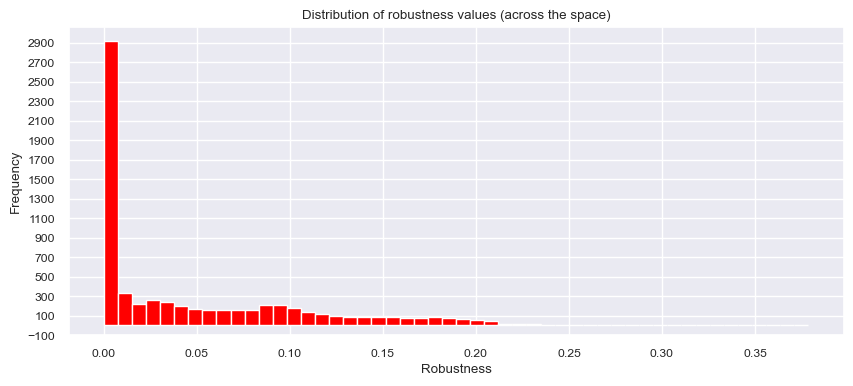

In [24]:
df.stack().plot.hist(bins=50, figsize=(10, 4), color='red')
plt.yticks(range(-100, 3001, 200))
plt.xlabel('Robustness')
plt.title('Distribution of robustness values (across the space)')
plt.show()

In [25]:
print(my_space.ALL_TRADEOFF_LABELS)

['average,average,average', 'average,average,highly-reliable', 'average,average,unreliable', 'average,fast,average', 'average,fast,highly-reliable', 'average,fast,unreliable', 'average,slow,average', 'average,slow,highly-reliable', 'average,slow,unreliable', 'cheap,average,average', 'cheap,average,highly-reliable', 'cheap,average,unreliable', 'cheap,fast,average', 'cheap,fast,highly-reliable', 'cheap,fast,unreliable', 'cheap,slow,average', 'cheap,slow,highly-reliable', 'cheap,slow,unreliable', 'expensive,average,average', 'expensive,average,highly-reliable', 'expensive,average,unreliable', 'expensive,fast,average', 'expensive,fast,highly-reliable', 'expensive,fast,unreliable', 'expensive,slow,average', 'expensive,slow,highly-reliable', 'expensive,slow,unreliable']


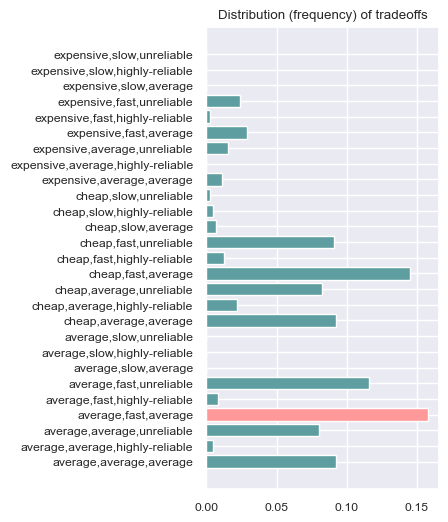

In [26]:
show_tradeoff_distribution(my_space, size=(3,6))

In [37]:
label_values_df = my_space.describe_labels(n_bins=3)
label_values_df

,objective,min,max,label
0,cost,0.900000,70.633333,cheap
1,cost,70.633333,140.366667,average
2,cost,140.366667,210.100000,expensive
3,executionTime,21.900000,52.633333,fast
4,executionTime,52.633333,83.366667,average
5,executionTime,83.366667,114.100000,slow
6,probSuccessfulExecution,25.900000,47.300000,highly-reliable
7,probSuccessfulExecution,47.300000,68.700000,average
8,probSuccessfulExecution,68.700000,90.100000,unreliable


In [28]:
print(my_space.experiments_df_.shape)
print(my_space.experiments_df_.shape[0] * 0.01)

(119700, 12)
1197.0


In [30]:
cart_model, rules, triple_rules = my_space.run_cart(key_parameters=kp, prune_tree=True, mass_min=0.02)
clf = cart_model.clf
print("nodes:", clf.tree_.node_count, "leaves:", clf.get_n_leaves())
print()
# print("Rules:")
# for r in rules:
#     print(r)

(119700, 4) Index(['deviceCost', 'lbExecTime', 'lbFailureProb', 'serviceCost'], dtype='object')
Running CART ... 0.02
nodes: 73 leaves: 56



In [62]:
# class_names =  list(set(my_space._get_cluster_labels()))
class_names = [*Counter(my_space._get_cluster_labels())] # Remove duplicates but keep the order
dot_data = tree.export_graphviz(clf, out_file=None, feature_names=kp, class_names=class_names,
                                filled=True, rounded=True, special_characters=True)
graph = graphviz.Source(dot_data)

print(tree.export_text(clf))
# pprint(tree.export_text(prunedTree))

# graph

|--- feature_2 <= 29.50
|   |--- feature_1 <= 35.50
|   |   |--- feature_0 <= 16.50
|   |   |   |--- class: 2
|   |   |--- feature_0 >  16.50
|   |   |   |--- feature_0 <= 33.50
|   |   |   |   |--- class: 5
|   |   |   |--- feature_0 >  33.50
|   |   |   |   |--- feature_3 <= 3.50
|   |   |   |   |   |--- class: 5
|   |   |   |   |--- feature_3 >  3.50
|   |   |   |   |   |--- class: 0
|   |--- feature_1 >  35.50
|   |   |--- feature_0 <= 15.50
|   |   |   |--- class: 10
|   |   |--- feature_0 >  15.50
|   |   |   |--- feature_2 <= 25.50
|   |   |   |   |--- class: 7
|   |   |   |--- feature_2 >  25.50
|   |   |   |   |--- class: 1
|--- feature_2 >  29.50
|   |--- feature_1 <= 36.50
|   |   |--- feature_0 <= 16.50
|   |   |   |--- feature_3 <= 2.50
|   |   |   |   |--- class: 6
|   |   |   |--- feature_3 >  2.50
|   |   |   |   |--- feature_0 <= 7.50
|   |   |   |   |   |--- class: 6
|   |   |   |   |--- feature_0 >  7.50
|   |   |   |   |   |--- feature_0 <= 12.50
|   |   |   |   |  

In [32]:
triple_rules

[[('<=', 'lbFailureProb', 29.5),
  ('<=', 'lbExecTime', 35.5),
  ('<=', 'deviceCost', 16.5),
  ('class', 'cheap,fast,unreliable', 0.6)],
 [('>', 'lbFailureProb', 29.5),
  ('<=', 'lbExecTime', 36.5),
  ('>', 'deviceCost', 16.5),
  ('<=', 'deviceCost', 32.5),
  ('class', 'average,fast,average', 0.66)],
 [('<=', 'lbFailureProb', 29.5),
  ('<=', 'lbExecTime', 35.5),
  ('>', 'deviceCost', 16.5),
  ('<=', 'deviceCost', 33.5),
  ('class', 'average,fast,unreliable', 0.61)],
 [('<=', 'lbFailureProb', 29.5),
  ('>', 'lbExecTime', 35.5),
  ('>', 'deviceCost', 15.5),
  ('<=', 'lbFailureProb', 25.5),
  ('class', 'average,average,unreliable', 0.58)],
 [('>', 'lbFailureProb', 29.5),
  ('>', 'lbExecTime', 36.5),
  ('>', 'deviceCost', 21.5),
  ('class', 'average,average,average', 0.66)],
 [('>', 'lbFailureProb', 29.5),
  ('<=', 'lbExecTime', 36.5),
  ('<=', 'deviceCost', 16.5),
  ('<=', 'serviceCost', 2.5),
  ('class', 'cheap,fast,average', 0.79)],
 [('<=', 'lbFailureProb', 29.5),
  ('>', 'lbExecTime',

In [35]:
for qa_label in my_space.available_tradeoffs_.keys():
    my_space.import_dataset(X_train, y_train)
    n = my_space.available_tradeoffs_[qa_label]
    
    if n > 0:
        print("Checking (with PRIM) ----")
        property_to_check = my_space.get_property_box(qa_label)
        print("  ", qa_label, property_to_check)
        
        box1, prange, prim_model = my_space.run_prim(property_to_check, threshold=0.8, method='emaw', key_parameters=kp, verbose=False)
        print("  New ranges:",  prange)

        if prange:
            my_space.import_dataset(X_test, y_test)
            my_space.adjust_parameters(prange)
            _ = my_space.discretize_outcomes(mins_maxs=MIN_MAX_RANGES)
            print("  Experiments:", my_space.experiments_df_.shape)

            print("  Computing robustness for all configurations...")
            df = my_space.compute_robustness_matrix()
            # print(df)
        # plt.show()

Checking (with PRIM) ----
   expensive,fast,unreliable {'cost': (140.36666666666667, 210.1), 'executionTime': (21.9, 52.633333333333326), 'probSuccessfulExecution': (68.69999999999999, 90.1)}


/Users/adiazpace/Documents/my-research/performance-models-cdp/Toy_Example/../archspace.py:406: UserWarning: DataFrame columns are not unique, some columns will be omitted.


  New ranges: {}
Checking (with PRIM) ----
   average,average,average {'cost': (70.63333333333334, 140.36666666666667), 'executionTime': (52.633333333333326, 83.36666666666666), 'probSuccessfulExecution': (47.3, 68.69999999999999)}


/Users/adiazpace/Documents/my-research/performance-models-cdp/Toy_Example/../archspace.py:406: UserWarning: DataFrame columns are not unique, some columns will be omitted.


  New ranges: {'lbExecTime': {'min': 39.0, 'max': 50.0}, 'deviceCost': {'min': 23.0, 'max': 38.0}, 'serviceCost': {'min': 2.0, 'max': 3.0}}
  Experiments: (2774, 12)
  Computing robustness for all configurations...


...

/Users/adiazpace/Documents/my-research/performance-models-cdp/Toy_Example/../archspace.py:406: UserWarning: DataFrame columns are not unique, some columns will be omitted.


  New ranges: {}
Checking (with PRIM) ----
   cheap,fast,highly-reliable {'cost': (0.9, 70.63333333333334), 'executionTime': (21.9, 52.633333333333326), 'probSuccessfulExecution': (25.9, 47.3)}


/Users/adiazpace/Documents/my-research/performance-models-cdp/Toy_Example/../archspace.py:406: UserWarning: DataFrame columns are not unique, some columns will be omitted.


  New ranges: {'lbExecTime': {'min': 10.0, 'max': 22.0}, 'serviceCost': {'min': 1.0, 'max': 4.0}, 'deviceCost': {'min': 1.0, 'max': 8.0}}
  Experiments: (2530, 12)
  Computing robustness for all configurations...


100%|██████████| 342/342 [00:06<00:00, 49.87it/s]


In [53]:
my_space.import_dataset(X_train, y_train)

qa_label = 'cheap,average,average' 
# ToyExample.get_property_box(qa_label, label_values_df)
property_to_check = my_space.get_property_box(qa_label)
print(qa_label, property_to_check)

cheap,average,average {'cost': (0.9, 70.63333333333334), 'executionTime': (52.633333333333326, 83.36666666666666), 'probSuccessfulExecution': (47.3, 68.69999999999999)}


In [54]:
policy = 4
box1, prange, prim_model = my_space.run_prim(property_to_check, threshold=0.8, method='emaw', key_parameters=kp, policy=policy)
prange

Instances satisfying property: True     231
False    129
Name: count, dtype: int64
Total instances: (360, 4)
Running PRIM ... emaw
1 possible boxes


/Users/adiazpace/Documents/my-research/performance-models-cdp/Toy_Example/../archspace.py:406: UserWarning: DataFrame columns are not unique, some columns will be omitted.


{'lbExecTime': {'min': 17.0, 'max': 35.0},
 'deviceCost': {'min': 2.0, 'max': 37.0},
 'lbFailureProb': {'min': 12.0, 'max': 48.0}}

In [55]:
# prim_model.boxes_to_dataframe() # Only for EMAW

/Users/adiazpace/opt/anaconda3/envs/perfmodels/lib/python3.11/site-packages/ema_workbench/analysis/scenario_discovery_util.py:929: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



box 1      
                min   max
lbExecTime     17.0  35.0
deviceCost      2.0  37.0
lbFailureProb  12.0  48.0

[<Figure size 640x480 with 1 Axes>]

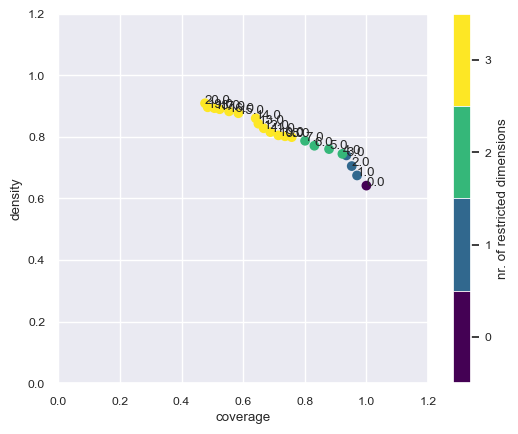

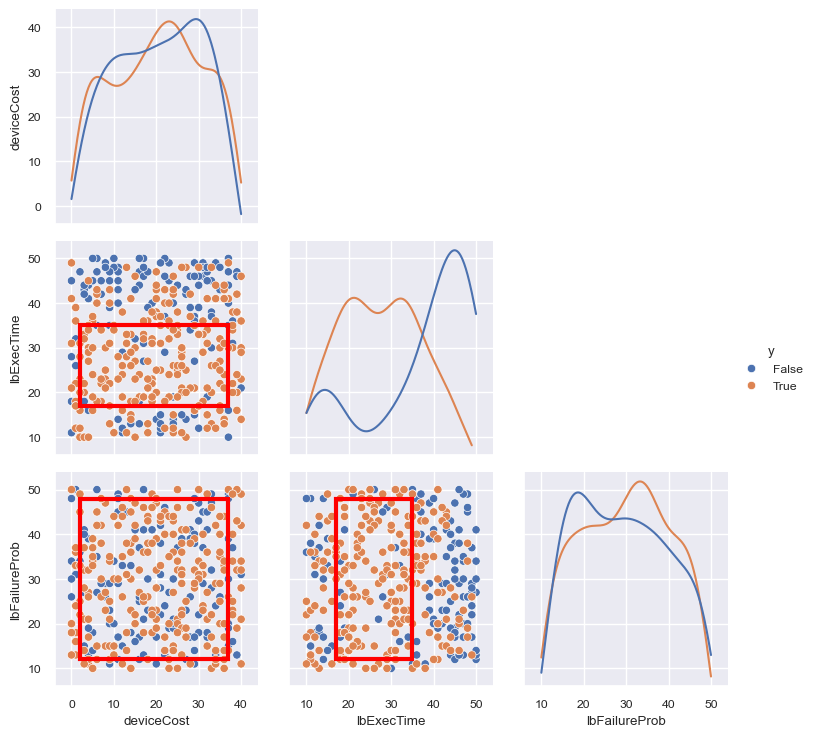

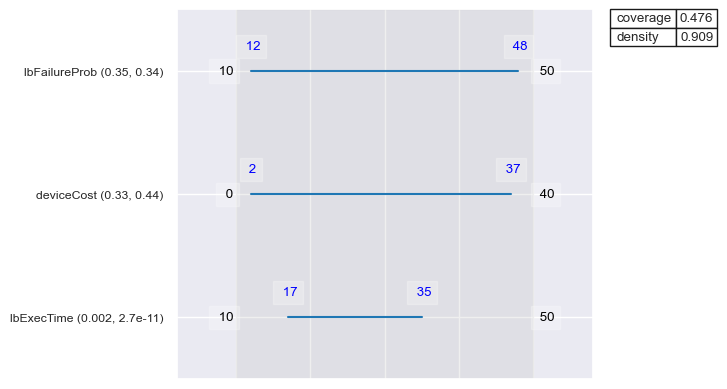

In [56]:
# EMAWorkbench
# fig = plt.figure(figsize=(24,12))
box1.show_tradeoff(annotated=True)
box1.show_pairs_scatter(upper='none', lower='scatter')
box1.inspect(style='graph')

In [ ]:
# Rhodium
# fig = plt.figure(figsize=(24,12))
# box1.show_tradeoff()
# box1.show_details()
# plt.show()

In [ ]:
# For Rhodium only
# boxes = my_space.run_prim(property_to_check, threshold=0.8, method='rhodium', key_parameters=kp, n_boxes=True)
# for idx, b in enumerate(boxes):
#     # print(ArchSpace.get_limits(b).shape)
#     box_shape = AWS_Microservices.get_box_limits(b).shape[0]
#     print("Box:", idx, AWS_Microservices.get_box_limits(b))
#     if box_shape > 0:
#         b.show_tradeoff()
#         b.show_details()
#         plt.show()

# AWS_Microservices.get_box_limits(box1)[['min', 'max']].to_dict(orient='index')

In [57]:
my_space.import_dataset(X_test, y_test)

Reducing range for tradeoff: cheap,average,average {'cost': (0.9, 70.63333333333334), 'executionTime': (52.633333333333326, 83.36666666666666), 'probSuccessfulExecution': (47.3, 68.69999999999999)}
New ranges: {'lbExecTime': {'min': 17.0, 'max': 35.0}, 'deviceCost': {'min': 2.0, 'max': 37.0}, 'lbFailureProb': {'min': 12.0, 'max': 48.0}}
Experiments: (17772, 12)


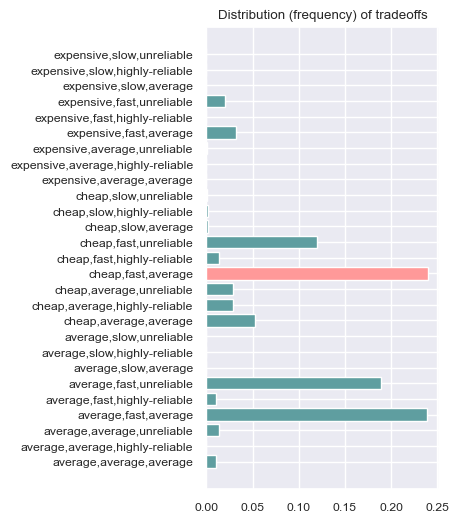

  Computing robustness for all configurations...


100%|██████████| 342/342 [00:24<00:00, 14.25it/s]


,1,2,3,4,5,6,7,8,9,10,...,333,334,335,336,337,338,339,340,341,342
"average,average,average",0.000000,0.000000,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00,...,0.000000,0.000000,0.02,0.064516,0.00,0.000000,0.016667,0.000000,0.019231,0.018868
"average,average,unreliable",0.000000,0.000000,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.042553,0.04,...,0.000000,0.000000,0.00,0.016129,0.00,0.000000,0.000000,0.000000,0.000000,0.000000
"average,fast,average",0.000000,0.000000,0.00,0.000000,0.000000,0.000000,0.000000,0.111111,0.127660,0.08,...,0.352941,0.393443,0.16,0.370968,0.30,0.250000,0.266667,0.370370,0.346154,0.358491
"average,fast,highly-reliable",0.000000,0.000000,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.021277,0.02,...,0.000000,0.016393,0.00,0.032258,0.00,0.000000,0.016667,0.000000,0.000000,0.000000
"average,fast,unreliable",0.000000,0.000000,0.00,0.000000,0.000000,0.000000,0.000000,0.037037,0.000000,0.06,...,0.313725,0.311475,0.26,0.096774,0.28,0.291667,0.383333,0.259259,0.250000,0.245283
"cheap,average,average",0.288136,0.396825,0.24,0.307692,0.387755,0.345455,0.380952,0.148148,0.148936,0.16,...,0.000000,0.000000,0.00,0.096774,0.00,0.000000,0.000000,0.000000,0.000000,0.000000
"cheap,average,highly-reliable",0.576271,0.523810,0.58,0.519231,0.408163,0.509091,0.523810,0.000000,0.000000,0.00,...,0.000000,0.000000,0.00,0.016129,0.00,0.000000,0.000000,0.000000,0.000000,0.000000
"cheap,average,unreliable",0.000000,0.031746,0.00,0.038462,0.020408,0.036364,0.015873,0.055556,0.085106,0.06,...,0.000000,0.000000,0.00,0.064516,0.00,0.000000,0.000000,0.000000,0.000000,0.000000
"cheap,fast,average",0.000000,0.000000,0.00,0.000000,0.000000,0.000000,0.000000,0.462963,0.319149,0.40,...,0.137255,0.049180,0.18,0.177419,0.14,0.187500,0.116667,0.092593,0.115385,0.113208
"cheap,fast,highly-reliable",0.050847,0.031746,0.04,0.038462,0.081633,0.054545,0.031746,0.055556,0.085106,0.08,...,0.000000,0.000000,0.00,0.016129,0.00,0.000000,0.000000,0.000000,0.000000,0.000000


In [58]:
print("Reducing range for tradeoff:", qa_label, property_to_check)
print("New ranges:",  prange)

my_space.adjust_parameters(prange)
_ = my_space.discretize_outcomes(mins_maxs=MIN_MAX_RANGES)
print("Experiments:", my_space.experiments_df_.shape)

show_tradeoff_distribution(my_space, size=(3,6))
# show_tradeoff_distribution(my_space, size=(4,3), in2D=True)

print("  Computing robustness for all configurations...")
df = my_space.compute_robustness_matrix()
df

In [59]:
print("Computing robustness for all configurations...")
main_dict = dict()
for exp in tqdm(my_space.get_configurations()):
    # print(exp)
    main_dict[str(exp)] = dict()
    for qa in my_space.available_tradeoffs_.keys():
        main_dict[str(exp)][qa], _ = my_space.compute_robustness(exp, qa)
df = pd.DataFrame.from_dict(main_dict, orient='columns').sort_index()
df

Computing robustness for all configurations...


100%|██████████| 342/342 [00:19<00:00, 17.60it/s]


,1,2,3,4,5,6,7,8,9,10,...,333,334,335,336,337,338,339,340,341,342
"average,average,average",0.000000,0.000000,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00,...,0.000000,0.000000,0.02,0.064516,0.00,0.000000,0.016667,0.000000,0.019231,0.018868
"average,average,unreliable",0.000000,0.000000,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.042553,0.04,...,0.000000,0.000000,0.00,0.016129,0.00,0.000000,0.000000,0.000000,0.000000,0.000000
"average,fast,average",0.000000,0.000000,0.00,0.000000,0.000000,0.000000,0.000000,0.111111,0.127660,0.08,...,0.352941,0.393443,0.16,0.370968,0.30,0.250000,0.266667,0.370370,0.346154,0.358491
"average,fast,highly-reliable",0.000000,0.000000,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.021277,0.02,...,0.000000,0.016393,0.00,0.032258,0.00,0.000000,0.016667,0.000000,0.000000,0.000000
"average,fast,unreliable",0.000000,0.000000,0.00,0.000000,0.000000,0.000000,0.000000,0.037037,0.000000,0.06,...,0.313725,0.311475,0.26,0.096774,0.28,0.291667,0.383333,0.259259,0.250000,0.245283
"cheap,average,average",0.288136,0.396825,0.24,0.307692,0.387755,0.345455,0.380952,0.148148,0.148936,0.16,...,0.000000,0.000000,0.00,0.096774,0.00,0.000000,0.000000,0.000000,0.000000,0.000000
"cheap,average,highly-reliable",0.576271,0.523810,0.58,0.519231,0.408163,0.509091,0.523810,0.000000,0.000000,0.00,...,0.000000,0.000000,0.00,0.016129,0.00,0.000000,0.000000,0.000000,0.000000,0.000000
"cheap,average,unreliable",0.000000,0.031746,0.00,0.038462,0.020408,0.036364,0.015873,0.055556,0.085106,0.06,...,0.000000,0.000000,0.00,0.064516,0.00,0.000000,0.000000,0.000000,0.000000,0.000000
"cheap,fast,average",0.000000,0.000000,0.00,0.000000,0.000000,0.000000,0.000000,0.462963,0.319149,0.40,...,0.137255,0.049180,0.18,0.177419,0.14,0.187500,0.116667,0.092593,0.115385,0.113208
"cheap,fast,highly-reliable",0.050847,0.031746,0.04,0.038462,0.081633,0.054545,0.031746,0.055556,0.085106,0.08,...,0.000000,0.000000,0.00,0.016129,0.00,0.000000,0.000000,0.000000,0.000000,0.000000


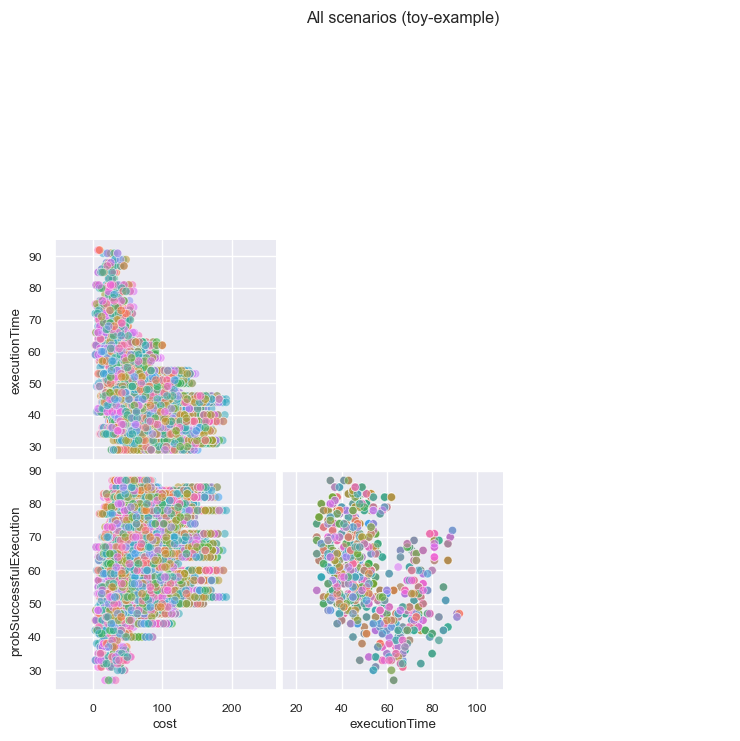

In [60]:
# show_pairplot(my_space, title='All scenarios (toy-example)', kind='sns')
show_pairplot(my_space, title='All scenarios (toy-example)', kind='sns', group='policy', legend=False) #, filename=None)
# show_pairplot(my_space, title='All scenarios (toy-example)', kind='sns', group='scenario', legend=False) #, filename=None)